<h1>Wildfire Data Visualization</h1>

In [1]:
%pip install seaborn
%pip install folium

In [2]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
import folium

In [3]:
pd.set_option("display.max_columns", None)

<h2>Data Importation</h2>

In [4]:
import requests

def download(url, filename):
    response = requests.get(url)
    try:
        if response.status_code == 200:
            print("url accessed")
            data = response.content
            with open(filename, "wb") as f:
                f.write(data)
                print(f"{filename} successfully written")
    except Exception as e:
        print("Error:", e)

In [5]:
url = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-DV0101EN-SkillsNetwork/Data%20Files/Historical_Wildfires.csv"
filename = "wildfire_database.csv"

In [6]:
download(url, filename)

url accessed
wildfire_database.csv successfully written


In [7]:
df = pd.read_csv(filename)
df.head()

,Region,Date,Estimated_fire_area,Mean_estimated_fire_brightness,Mean_estimated_fire_radiative_power,Mean_confidence,Std_confidence,Var_confidence,Count,Replaced
0,NSW,1/4/2005,8.68000,312.266667,42.400000,78.666667,2.886751,8.333333,3,R
1,NSW,1/5/2005,16.61125,322.475000,62.362500,85.500000,8.088793,65.428571,8,R
2,NSW,1/6/2005,5.52000,325.266667,38.400000,78.333333,3.214550,10.333333,3,R
3,NSW,1/7/2005,6.26400,313.870000,33.800000,92.200000,7.529940,56.700000,5,R
4,NSW,1/8/2005,5.40000,337.383333,122.533333,91.000000,7.937254,63.000000,3,R


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 26406 entries, 0 to 26405
Data columns (total 10 columns):
 #   Column                               Non-Null Count  Dtype  
---  ------                               --------------  -----  
 0   Region                               26406 non-null  object 
 1   Date                                 26406 non-null  object 
 2   Estimated_fire_area                  26406 non-null  float64
 3   Mean_estimated_fire_brightness       26406 non-null  float64
 4   Mean_estimated_fire_radiative_power  26406 non-null  float64
 5   Mean_confidence                      26406 non-null  float64
 6   Std_confidence                       24199 non-null  float64
 7   Var_confidence                       24199 non-null  float64
 8   Count                                26406 non-null  int64  
 9   Replaced                             26406 non-null  object 
dtypes: float64(6), int64(1), object(3)
memory usage: 1.7+ MB


In [9]:
df.isna().sum()

Region                                    0
Date                                      0
Estimated_fire_area                       0
Mean_estimated_fire_brightness            0
Mean_estimated_fire_radiative_power       0
Mean_confidence                           0
Std_confidence                         2207
Var_confidence                         2207
Count                                     0
Replaced                                  0
dtype: int64

In [10]:
(df[df.columns]=="").sum()

Region                                 0
Date                                   0
Estimated_fire_area                    0
Mean_estimated_fire_brightness         0
Mean_estimated_fire_radiative_power    0
Mean_confidence                        0
Std_confidence                         0
Var_confidence                         0
Count                                  0
Replaced                               0
dtype: int64

In [11]:
df.columns

Index(['Region', 'Date', 'Estimated_fire_area',
       'Mean_estimated_fire_brightness', 'Mean_estimated_fire_radiative_power',
       'Mean_confidence', 'Std_confidence', 'Var_confidence', 'Count',
       'Replaced'],
      dtype='object')

In [12]:
import datetime as dt
df["Year"] = pd.to_datetime(df["Date"]).dt.year
df["Month"]= pd.to_datetime(df["Date"]).dt.month
df["Date"] = pd.to_datetime(df["Date"])

In [13]:
df.head()

,Region,Date,Estimated_fire_area,Mean_estimated_fire_brightness,Mean_estimated_fire_radiative_power,Mean_confidence,Std_confidence,Var_confidence,Count,Replaced,Year,Month
0,NSW,2005-01-04,8.68000,312.266667,42.400000,78.666667,2.886751,8.333333,3,R,2005,1
1,NSW,2005-01-05,16.61125,322.475000,62.362500,85.500000,8.088793,65.428571,8,R,2005,1
2,NSW,2005-01-06,5.52000,325.266667,38.400000,78.333333,3.214550,10.333333,3,R,2005,1
3,NSW,2005-01-07,6.26400,313.870000,33.800000,92.200000,7.529940,56.700000,5,R,2005,1
4,NSW,2005-01-08,5.40000,337.383333,122.533333,91.000000,7.937254,63.000000,3,R,2005,1


In [14]:
df.dtypes

Region                                         object
Date                                   datetime64[ns]
Estimated_fire_area                           float64
Mean_estimated_fire_brightness                float64
Mean_estimated_fire_radiative_power           float64
Mean_confidence                               float64
Std_confidence                                float64
Var_confidence                                float64
Count                                           int64
Replaced                                       object
Year                                            int32
Month                                           int32
dtype: object

<h2>Change in Average Estimated Fire Area Over Time</h2>

In [15]:
print(df["Region"].unique())
print(df["Year"].unique())

['NSW' 'NT' 'QL' 'SA' 'TA' 'VI' 'WA']
[2005 2006 2007 2008 2009 2010 2011 2012 2013 2014 2015 2016 2017 2018
 2019 2020]


<h3>Change in average estimated fire area over years</h3>

In [16]:
df_area_years = df.groupby(by = "Year")["Estimated_fire_area"].mean().reset_index()
df_area_years

,Year,Estimated_fire_area
0,2005,92.770501
1,2006,176.289434
2,2007,153.112464
3,2008,99.758968
4,2009,141.624955
5,2010,62.429968
6,2011,266.936175
7,2012,265.526196
8,2013,95.896092
9,2014,144.007348


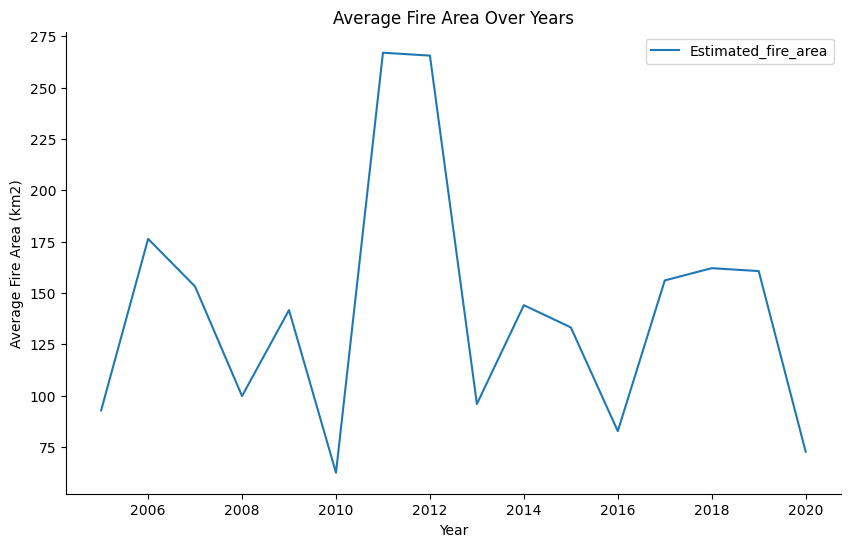

In [17]:
df_area_years.plot(x = "Year", y = "Estimated_fire_area", figsize=(10, 6))
plt.xlabel("Year")
plt.ylabel("Average Fire Area (km2)")
plt.title("Average Fire Area Over Years")
sns.despine()
plt.show()

<h3>Change in average estimated fire area by region over years</h3>

In [18]:
df_area_region_year = df.groupby(by = ["Region", "Year"])["Estimated_fire_area"].mean().reset_index()
df_pivot = df_area_region_year.pivot(index = "Year", columns = "Region", values = "Estimated_fire_area").reset_index()
df_pivot

Region,Year,NSW,NT,QL,SA,TA,VI,WA
0,2005,26.863630,130.447265,139.057603,24.393670,13.190805,25.891571,141.143190
1,2006,46.901998,345.694251,154.459184,27.241479,17.003523,112.577309,317.945624
2,2007,18.836878,356.847073,102.365196,38.305468,17.087371,54.617235,236.312894
3,2008,12.031560,151.619520,119.370678,13.070088,15.268353,21.744313,158.002330
4,2009,24.194192,237.454020,221.604992,9.188660,10.604640,42.536863,172.400310
5,2010,12.254727,115.754595,55.519273,20.351840,9.121465,30.867031,86.820558
6,2011,42.111691,717.106961,295.932551,59.550894,7.966905,47.060126,237.140752
7,2012,25.255396,402.792033,316.285115,74.645162,11.566210,24.078344,557.470599
8,2013,33.505832,127.164659,132.540480,32.849540,26.288843,32.522269,156.084995
9,2014,25.834290,299.319794,121.850504,44.806038,8.918733,50.678448,242.097831


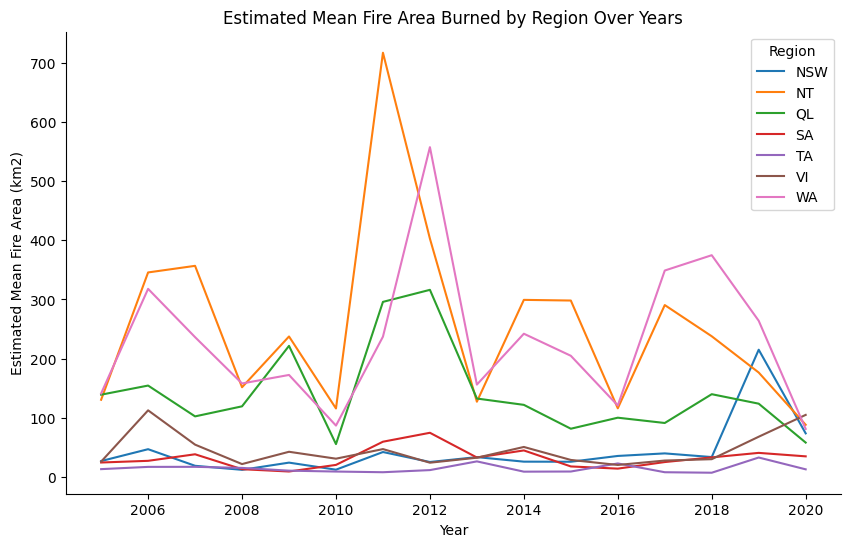

In [19]:
df_pivot.plot(x = "Year", figsize=(10,6))
plt.xlabel("Year")
plt.ylabel("Estimated Mean Fire Area (km2)")
plt.title("Estimated Mean Fire Area Burned by Region Over Years")
sns.despine()
plt.show()

<h2>Estimated Fire Area for Year Grouped by Month for 2010 to 2013</h2>

In [20]:
df_date_index =df.set_index("Date")
df_year_month = df_date_index["Estimated_fire_area"].resample("ME").mean() 

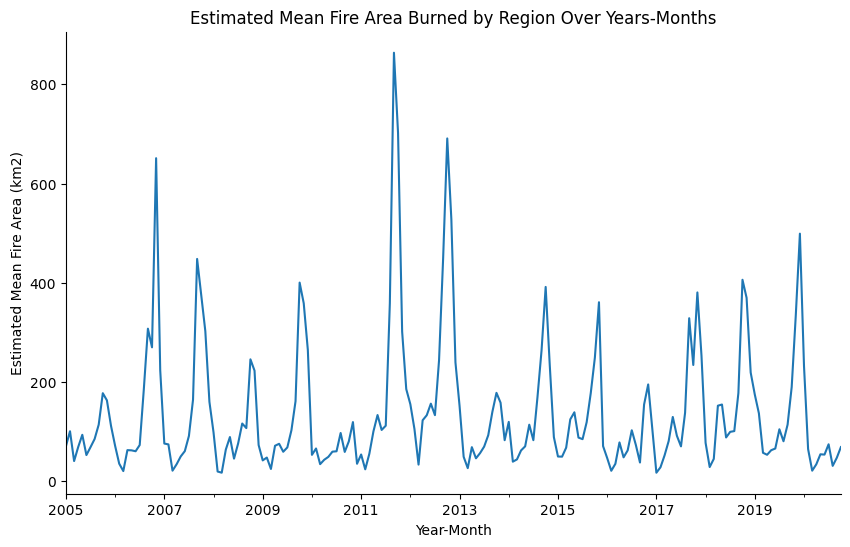

In [21]:
df_year_month.plot(figsize=(10,6))
plt.xlabel("Year-Month")
plt.ylabel("Estimated Mean Fire Area (km2)")
plt.title("Estimated Mean Fire Area Burned by Region Over Years-Months")
sns.despine()
plt.show()

In [22]:
df_10_13 = df_date_index.sort_index().loc["2010":"2013"]
df_plot = df_10_13["Estimated_fire_area"].resample("ME").mean()

In [23]:
df_plot

Date
2010-01-31     53.430312
2010-02-28     66.264381
2010-03-31     34.694920
2010-04-30     43.528625
2010-05-31     49.347853
2010-06-30     59.856843
2010-07-31     60.626592
2010-08-31     97.497126
2010-09-30     59.339218
2010-10-31     80.664494
2010-11-30    119.433015
2010-12-31     35.456566
2011-01-31     54.154307
2011-02-28     24.285958
2011-03-31     55.628141
2011-04-30    100.812237
2011-05-31    133.642794
2011-06-30    103.611263
2011-07-31    112.124965
2011-08-31    359.140796
2011-09-30    863.788532
2011-10-31    701.998658
2011-11-30    301.700948
2011-12-31    185.920414
2012-01-31    155.472477
2012-02-29    105.520004
2012-03-31     33.763152
2012-04-30    123.120114
2012-05-31    133.253825
2012-06-30    156.588780
2012-07-31    133.421678
2012-08-31    244.132324
2012-09-30    450.365960
2012-10-31    691.053631
2012-11-30    528.070641
2012-12-31    239.673279
2013-01-31    152.299439
2013-02-28     49.495502
2013-03-31     26.642232
2013-04-30     68.92

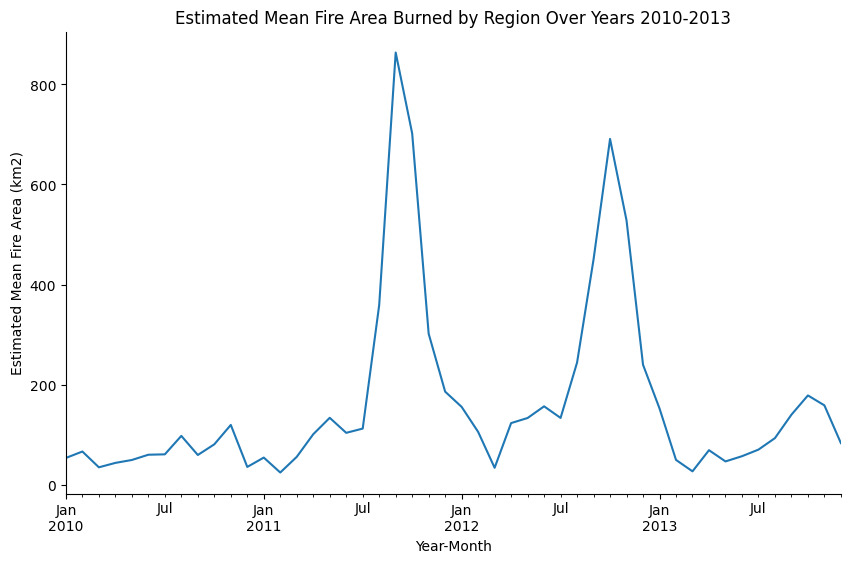

In [24]:
df_plot.plot(figsize=(10,6))
plt.xlabel("Year-Month")
plt.ylabel("Estimated Mean Fire Area (km2)")
plt.title("Estimated Mean Fire Area Burned by Region Over Years 2010-2013")
sns.despine()
plt.show()

<h3>Distribution of Mean Estimated Fire Brightness Across the Regions</h3>

In [25]:
#df_mean_fire_brightness = df.groupby(by="Region")["Mean_estimated_fire_brightness"].mean().reset_index()
#df_mean_fire_brightness
#Not needed with Seaborn. Automatiocally aggreagates raw data for categorical variables.

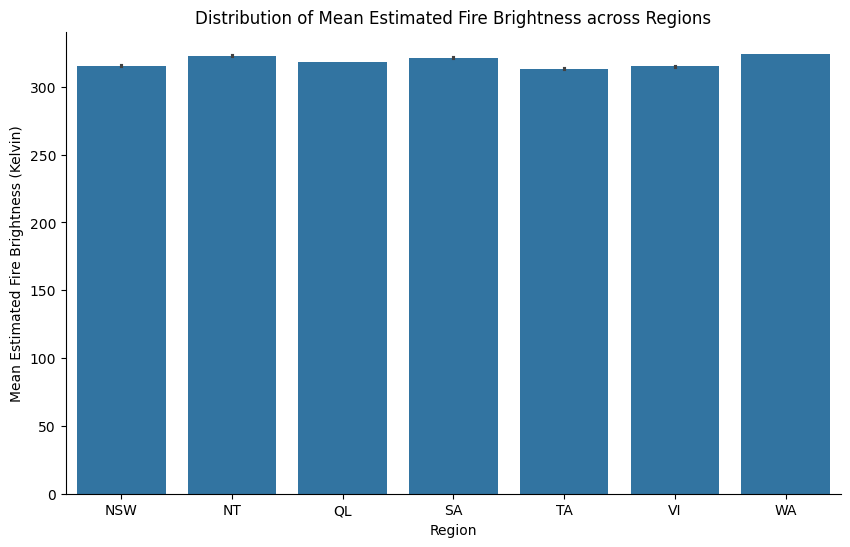

In [26]:
plt.figure(figsize=(10,6))
sns.barplot(data = df,x = "Region", y = "Mean_estimated_fire_brightness")
plt.xlabel('Region')
plt.ylabel('Mean Estimated Fire Brightness (Kelvin)')
plt.title('Distribution of Mean Estimated Fire Brightness across Regions')
sns.despine()
plt.show()

<h3>Portion of Count of Pixels for Presumed Vegetation Fires Varying Across Regions</h3>

In [27]:
df_fire_count = df.groupby("Region")["Count"].sum().reset_index()
df_fire_count

,Region,Count
0,NSW,117412
1,NT,649430
2,QL,420882
3,SA,35160
4,TA,11473
5,VI,52473
6,WA,615968


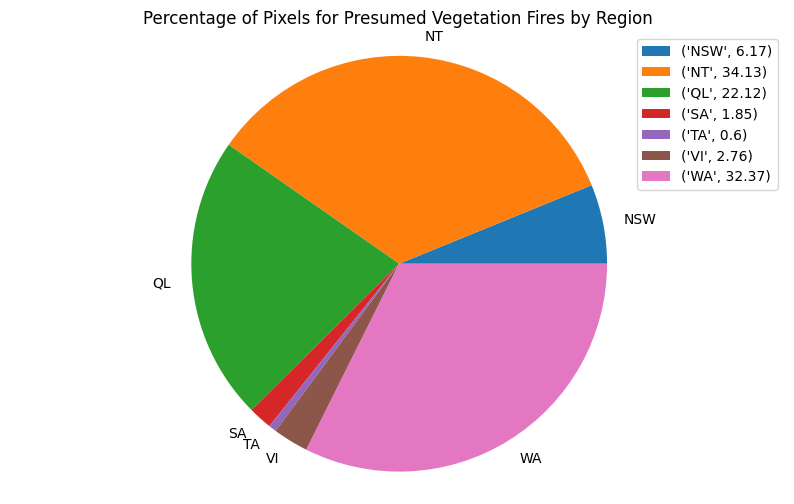

In [28]:
plt.figure(figsize=(10,6))
plt.pie(df_fire_count["Count"], labels = df_fire_count["Region"])
plt.title("Percentage of Pixels for Presumed Vegetation Fires by Region") #autopct="%1.1f%%"
plt.legend([(i,round(k/df_fire_count["Count"].sum()*100,2)) for i,k in zip(df_fire_count["Region"], df_fire_count["Count"])])
plt.axis("equal")
plt.show()

<h3>Histogram of the Mean Estimated Fire Brightness</h3>

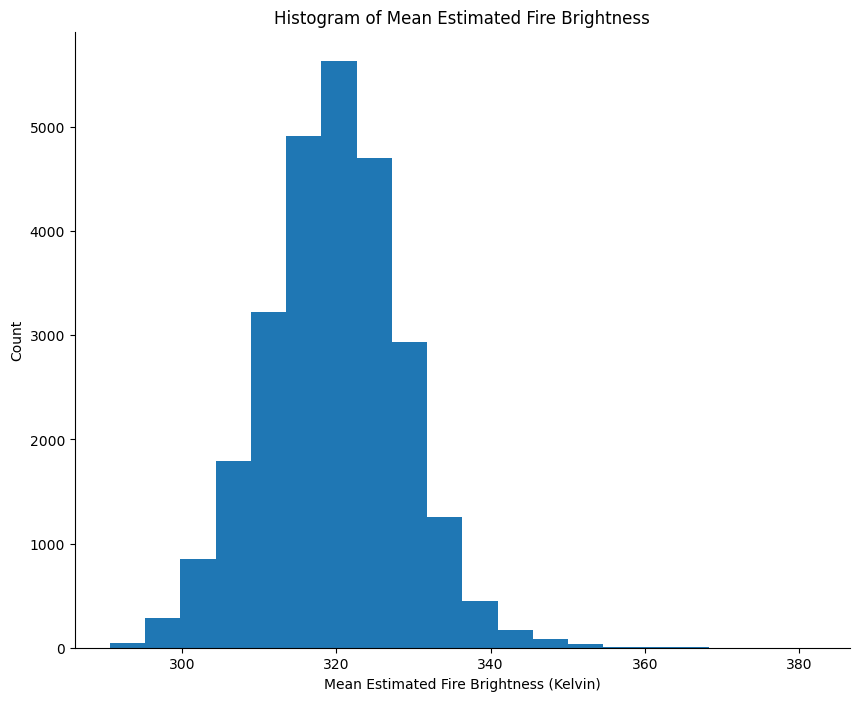

In [29]:
plt.figure(figsize=(10,8))
plt.hist(x = df["Mean_estimated_fire_brightness"], bins = 20)
plt.xlabel('Mean Estimated Fire Brightness (Kelvin)')
plt.ylabel('Count')
plt.title('Histogram of Mean Estimated Fire Brightness')
sns.despine()
plt.show()

<h3>Distribution of Estimated Fire Brightness Across Regions</h3>

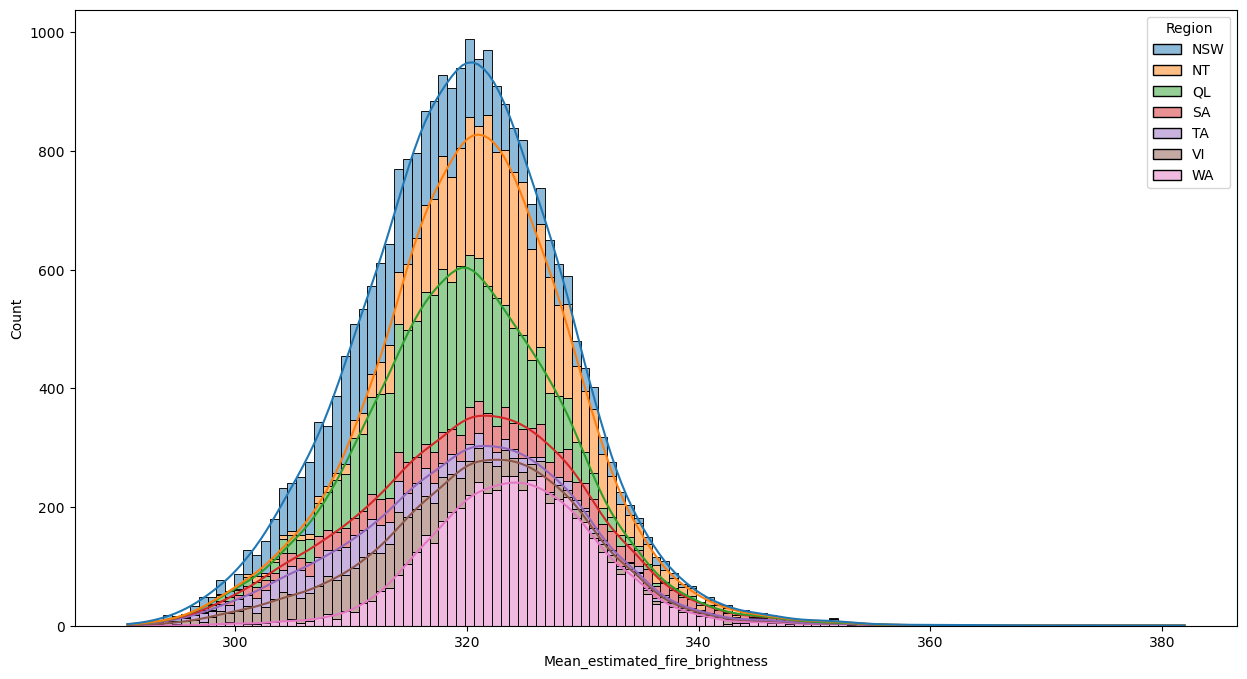

In [30]:
plt.figure(figsize=(15,8))
sns.histplot(df, x= "Mean_estimated_fire_brightness", kde = True, hue = "Region", multiple = "stack" )
plt.show()

<h3>Correlation Between Mean Estimated Fire Radiative Power and Mean Confidence Level</h3>

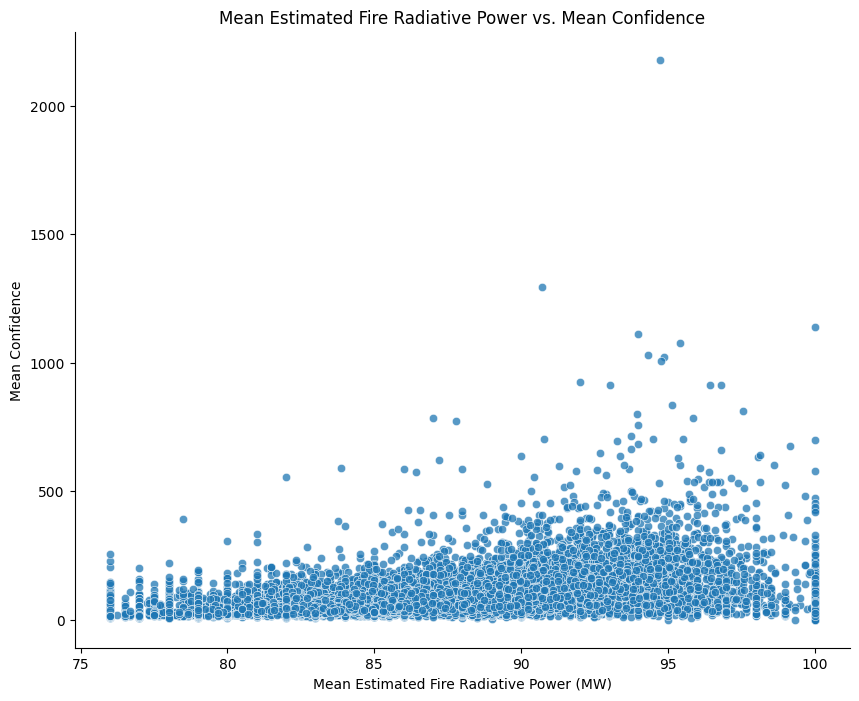

In [31]:
plt.figure(figsize=(10,8))
sns.scatterplot(df, y = "Mean_estimated_fire_radiative_power", x = "Mean_confidence", alpha = 0.75)
plt.xlabel("Mean Estimated Fire Radiative Power (MW)")
plt.ylabel("Mean Confidence")
plt.title("Mean Estimated Fire Radiative Power vs. Mean Confidence")
sns.despine()
plt.show()

<h3>Fire Map of Australia for Seven Regions</h3>

In [32]:
region_data = {'region':['NSW','QL','SA','TA','VI','WA','NT'], 'Lat':[-31.8759835,-22.1646782,-30.5343665,-42.035067,-36.5986096,-25.2303005,-19.491411], 
               'Lon':[147.2869493,144.5844903,135.6301212,146.6366887,144.6780052,121.0187246,132.550964]}
reg=pd.DataFrame(region_data)
reg

,region,Lat,Lon
0,NSW,-31.875984,147.286949
1,QL,-22.164678,144.584490
2,SA,-30.534367,135.630121
3,TA,-42.035067,146.636689
4,VI,-36.598610,144.678005
5,WA,-25.230300,121.018725
6,NT,-19.491411,132.550964


In [33]:
region_map_feature = folium.FeatureGroup()
aus_map = folium.Map(location = [-25, 135], zoom_start = 4)

for lat,lon,label in zip(reg.Lat, reg.Lon, reg.region):
    region_map_feature.add_child(
        folium.features.CircleMarker(
            [lat,lon],
            popup = label,
            color = "Red",
            fill = True,
            fill_color = "yellow",
            fill_opacity = 0.5
        )
    )

aus_map.add_child(region_map_feature)